# 01. Getting Started with `dyno.py`: Stochastic DSGE Modeling

[`dyno.py`](https://github.com/EconForge/dyno.py) is a modern, high-performance Python package for specifying, solving, and simulating Dynamic Stochastic General Equilibrium (DSGE) models.

In this notebook, you will learn the core workflow for stochastic models:
1. **Loading a Model**: From a native `.dyno` file or an inline Python string.
2. **Model Inspection**: Variables, parameters, equations, and steady states.
3. **Checking Stability**: Residuals and the Blanchard-Kahn rank condition.
4. **Solving via 1st-Order Perturbation**: Decision rules and policy functions.
5. **Impulse Response Functions (IRFs)**: Computing and plotting responses to shocks.
6. **Stochastic Simulation & Moments**: Simulating time series and computing variance-covariance matrices.
7. **Recalibration on the Fly**: Modifying parameters and re-solving dynamically.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dyno import DynoModel, simulate, irfs

# Configure display options
pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 10)


## 1. Loading a Model

Dyno models are typically written in clean, human-readable `.dyno` files. Let's load the canonical Real Business Cycle (RBC) model located in `models/rbc.dyno`.


In [2]:
# Load model from file
model = DynoModel("models/rbc.dyno")
print(f"Loaded model: {model.name}")


Loaded model: rbc


### Prototyping Inline with Python Strings
You can also define and solve models dynamically in Python without creating a separate file, using the `txt` argument:


In [3]:
# Inline model example: simple AR(1) endowment process
toy_txt = '''
rho   <- 0.85
sigma <- 0.02
x[~]  <- 0.0
e[t]  <- N(0, sigma^2)
x[t] = rho * x[t-1] + e[t]
'''

toy_model = DynoModel(txt=toy_txt)
toy_sol = toy_model.solve()
print("Toy model decision rule:")
display(toy_sol.decision_rule.coefficients_as_df())


Toy model decision rule:


(     x
 0  0.0,
       x[t-1]  e[t]
 x[t]    0.85   1.0)

## 2. Inspecting Model Structure

Dyno parses your model equations and organizes variables and parameters:


In [4]:
print("Endogenous variables :", model.symbols["endogenous"])
print("Exogenous shocks     :", model.symbols["exogenous"])
print("Parameters           :", model.symbols["parameters"])
print("Total equations      :", len(model.equations))


Endogenous variables : ['r', 'n', 'k', 'y', 'i', 'c', 'w', 'a']
Exogenous shocks     : ['epsilon']
Parameters           : ['beta', 'delta', 'nss', 'eta', 'alpha', 'rho', 'chi']
Total equations      : 8


### Steady State & Residuals
Let's inspect the calculated steady-state values and verify that the equation residuals are virtually zero:


In [5]:
# Display steady-state values as a table
ss_df = pd.DataFrame.from_dict(model.steady_state, orient='index', columns=['Steady State Value'])
ss_df


,Steady State Value
a,1.0000
r,0.0402
n,0.3300
k,6.9655
y,0.8757
w,1.8044
i,0.1741
c,0.7015
epsilon,0.0000


In [6]:
# Verify equation residuals at steady state
residuals = model.residuals
print(f"Maximum absolute residual: {np.max(np.abs(residuals)):.2e}")
assert np.allclose(residuals, 0, atol=1e-6), "Residuals must be close to 0"
print("✓ Steady state is exact!")


Maximum absolute residual: 8.88e-16
✓ Steady state is exact!


## 3. Checking the Blanchard-Kahn Conditions

Before solving, `model.check()` evaluates the generalized eigenvalues of the system to check the **Blanchard-Kahn conditions** (the number of eigenvalues outside the unit circle must match the number of forward-looking / non-predetermined variables for a unique stable saddle-path solution).


In [7]:
model.check()


equations,8,
variables,9,
endogenous,8,"r, n, k, y, i, c, w, a"
exogenous,1,epsilon
constants,7,"beta, delta, nss, eta, alpha, rho, chi"


## 4. Solving the Model (1st-Order Perturbation)

`model.solve()` computes the linear perturbation solution (recursive decision rule):
$$y_t = y^* + A (y_{t-1} - y^*) + B \epsilon_t$$

Where:
- $y^*$ is the steady state vector
- $A$ is the transition matrix for predetermined/lagged states
- $B$ is the impact matrix for exogenous shocks


In [8]:
solution = model.solve()
dr = solution.decision_rule

# Display the decision rule Jacobian (policy functions)
coef_df = dr.coefficients_as_df()
coef_df


(        r     n       k       y       i       c       w    a
 0  0.0402  0.33  6.9655  0.8757  0.1741  0.7015  1.8044  1.0,
       r[t-1]  n[t-1]  k[t-1]  y[t-1]  i[t-1]  c[t-1]  w[t-1]  a[t-1]  \
 r[t]     0.0     0.0 -0.0049     0.0     0.0     0.0     0.0  0.0560   
 n[t]     0.0     0.0 -0.0122     0.0     0.0     0.0     0.0  0.2387   
 k[t]     0.0     0.0  0.9398     0.0     0.0     0.0     0.0  0.9997   
 y[t]     0.0     0.0  0.0182     0.0     0.0     0.0     0.0  1.2188   
 i[t]     0.0     0.0 -0.0352     0.0     0.0     0.0     0.0  0.9997   
 c[t]     0.0     0.0  0.0533     0.0     0.0     0.0     0.0  0.2191   
 w[t]     0.0     0.0  0.1043     0.0     0.0     0.0     0.0  1.2063   
 a[t]     0.0     0.0  0.0000     0.0     0.0     0.0     0.0  0.9000   
 
       epsilon[t]  
 r[t]      0.0622  
 n[t]      0.2652  
 k[t]      1.1107  
 y[t]      1.3542  
 i[t]      1.1107  
 c[t]      0.2434  
 w[t]      1.3404  
 a[t]      1.0000  )

## 5. Impulse Response Functions (IRFs)

Dyno computes impulse response functions across a chosen horizon $T$. You can request:
- `"log-deviation"`: Percentage deviations from steady state ($100 \times \frac{y_t - y^*}{y^*}$)
- `"deviation"`: Level differences ($y_t - y^*$)
- `"level"`: Raw variable values ($y_t$)


In [9]:
# Generate 40-period IRFs in log-deviations
irf_dict = solution.irfs(type="log-deviation", T=40)

# Inspect the response to the TFP shock (epsilon)
tfp_irf = irf_dict["epsilon"]
tfp_irf.head(10)


,r,n,k,y,i,c,w,a
0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,1.3918,0.7233,0.1435,1.3918,5.7407,0.3123,0.6686,0.9000
2,1.1299,0.6139,0.2641,1.2734,4.9649,0.3571,0.6595,0.8100
3,0.9015,0.5178,0.3644,1.1656,4.2787,0.3928,0.6478,0.7290
4,0.7029,0.4333,0.4471,1.0673,3.6726,0.4207,0.6341,0.6561
5,0.5307,0.3592,0.5144,0.9778,3.1378,0.4417,0.6186,0.5905
6,0.3819,0.2944,0.5682,0.8963,2.6665,0.4568,0.6018,0.5314
7,0.2537,0.2378,0.6103,0.8218,2.2519,0.4669,0.5840,0.4783
8,0.1437,0.1885,0.6422,0.7540,1.8876,0.4726,0.5654,0.4305
9,0.0498,0.1457,0.6654,0.6920,1.5681,0.4745,0.5463,0.3874


### Built-in Interactive Visualization
`solution.plot()` produces interactive Plotly figures out of the box:


In [10]:
fig = solution.plot(type="log-deviation")
# Adjust figure size for notebook display
fig.update_layout(height=500, width=800, title="Impulse Responses to TFP Shock (log-deviation)")
fig.show()


## 6. Stochastic Simulation & Moments

We can generate simulated paths under random shock draws using `simulate(solution, T=...)`:


In [11]:
# Simulate 120 periods (e.g. 30 years of quarterly data)
sim_df = simulate(solution, T=120)
sim_df.head(10)


,r,n,k,y,i,c,w,a
0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,-0.0002,-0.0008,-0.0034,-0.0042,-0.0034,-0.0007,-0.0041,-0.0031
2,-0.0003,-0.0015,-0.0097,-0.0079,-0.0063,-0.0016,-0.0082,-0.0058
3,-0.0008,-0.0037,-0.0250,-0.0196,-0.0156,-0.0040,-0.0202,-0.0143
4,-0.0009,-0.0042,-0.0425,-0.0236,-0.0181,-0.0055,-0.0255,-0.0171
5,-0.0013,-0.0060,-0.0671,-0.0338,-0.0256,-0.0082,-0.0372,-0.0244
6,0.0002,0.0001,-0.0660,-0.0049,-0.0006,-0.0042,-0.0106,-0.0027
7,0.0005,0.0016,-0.0587,0.0028,0.0056,-0.0028,-0.0029,0.0030
8,0.0014,0.0055,-0.0350,0.0235,0.0222,0.0013,0.0182,0.0182
9,0.0017,0.0070,-0.0053,0.0330,0.0288,0.0042,0.0296,0.0248


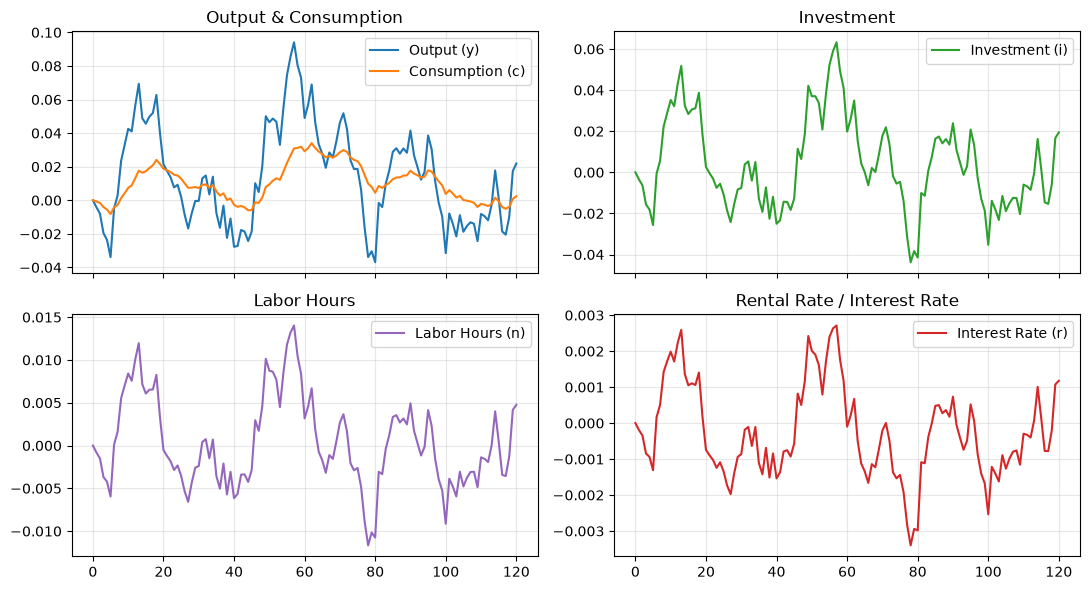

In [12]:
# Plot selected simulated trajectories
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)

axes[0, 0].plot(sim_df["y"], label="Output (y)", color="#1f77b4", lw=1.5)
axes[0, 0].plot(sim_df["c"], label="Consumption (c)", color="#ff7f0e", lw=1.5)
axes[0, 0].set_title("Output & Consumption")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(sim_df["i"], label="Investment (i)", color="#2ca02c", lw=1.5)
axes[0, 1].set_title("Investment")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(sim_df["n"], label="Labor Hours (n)", color="#9467bd", lw=1.5)
axes[1, 0].set_title("Labor Hours")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(sim_df["r"], label="Interest Rate (r)", color="#d62728", lw=1.5)
axes[1, 1].set_title("Rental Rate / Interest Rate")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Analytical Moments
Dyno can also compute the exact analytical unconditional and conditional covariance matrices:


In [13]:
cov_uncond, cov_cond = dr.moments()
var_names = model.symbols["endogenous"]

cov_df = pd.DataFrame(cov_uncond, index=var_names, columns=var_names)
print("Unconditional Covariance Matrix:")
cov_df


Unconditional Covariance Matrix:


,r,n,k,y,i,c,w,a
r,3.1350e-07,1.3364e-06,5.5973e-06,6.8240e-06,5.5973e-06,1.2267e-06,6.7543e-06,5.0392e-06
n,1.3364e-06,5.6969e-06,2.3860e-05,2.9090e-05,2.3860e-05,5.2293e-06,2.8793e-05,2.1481e-05
k,5.5973e-06,2.3860e-05,9.9935e-05,1.2184e-04,9.9935e-05,2.1902e-05,1.2059e-04,8.9971e-05
y,6.8240e-06,2.9090e-05,1.2184e-04,1.4854e-04,1.2184e-04,2.6702e-05,1.4702e-04,1.0969e-04
i,5.5973e-06,2.3860e-05,9.9935e-05,1.2184e-04,9.9935e-05,2.1902e-05,1.2059e-04,8.9971e-05
c,1.2267e-06,5.2293e-06,2.1902e-05,2.6702e-05,2.1902e-05,4.8001e-06,2.6429e-05,1.9718e-05
w,6.7543e-06,2.8793e-05,1.2059e-04,1.4702e-04,1.2059e-04,2.6429e-05,1.4552e-04,1.0857e-04
a,5.0392e-06,2.1481e-05,8.9971e-05,1.0969e-04,8.9971e-05,1.9718e-05,1.0857e-04,8.1000e-05


## 7. Model Recalibration on the Fly

You can modify parameter values and re-solve without editing or re-parsing the original model file using `model.recalibrate()`:


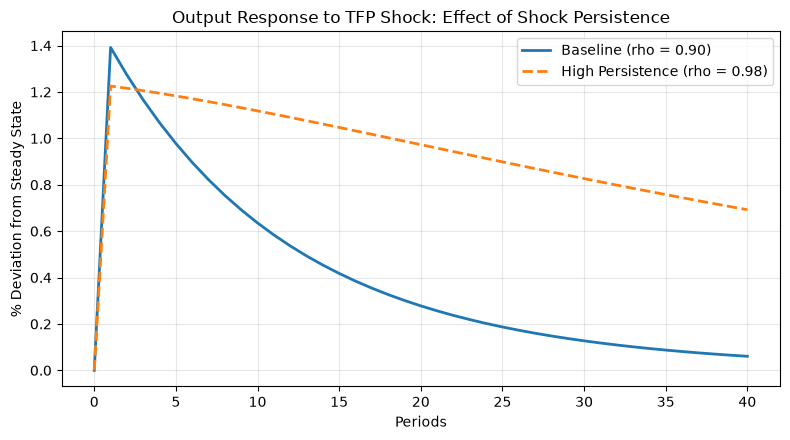

In [14]:
# Recalibrate TFP persistence (rho) from 0.90 to 0.98
model_high_rho = model.recalibrate(rho=0.98)
sol_high_rho = model_high_rho.solve()

# Compare the output IRF between baseline and high persistence
irf_base = solution.irfs(type="log-deviation", T=40)["epsilon"]["y"]
irf_high = sol_high_rho.irfs(type="log-deviation", T=40)["epsilon"]["y"]

comp_df = pd.DataFrame({
    "Baseline (rho = 0.90)": irf_base,
    "High Persistence (rho = 0.98)": irf_high
})

plt.figure(figsize=(8, 4.5))
plt.plot(comp_df.index, comp_df["Baseline (rho = 0.90)"], label="Baseline (rho = 0.90)", lw=2)
plt.plot(comp_df.index, comp_df["High Persistence (rho = 0.98)"], label="High Persistence (rho = 0.98)", lw=2, linestyle="--")
plt.title("Output Response to TFP Shock: Effect of Shock Persistence")
plt.xlabel("Periods")
plt.ylabel("% Deviation from Steady State")
plt.grid(True, alpha=0.3)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()
